In [1]:
import os
import json
import math
import copy

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

In [2]:
with open("data_split.json", "r") as f:
    split_data = json.load(f)

train_subjects = split_data["train"]
val_subjects = split_data["validation"]
test_subjects = split_data["test"]

print("Train:", len(train_subjects))
print("Validation:", len(val_subjects))
print("Test:", len(test_subjects))

Train: 1000
Validation: 125
Test: 126


In [3]:
train_data = r"Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

In [4]:
def preprocess_t2f(image):
    # Expected original BraTS shape
    if image.shape != (240, 240, 155):
        raise ValueError(
            f"Unexpected image shape: {image.shape}"
        )

    # Crop to 208 x 224 x 155
    image = image[16:224, 8:232, :]

    # Pad depth to 160
    image = np.pad(
        image,
        ((0, 0), (0, 0), (2, 3)),
        mode="constant",
        constant_values=0
    )

    foreground = image > 0

    if not np.any(foreground):
        raise ValueError(
            "No foreground voxels found"
        )

    # Robust upper intensity clipping
    upper = np.percentile(
        image[foreground],
        99.9
    )

    image = np.clip(
        image,
        0,
        upper
    )

    # Normalize foreground to [0, 1]
    image = image / upper

    # Map whole volume to [-1, 1]
    image = image * 2.0 - 1.0

    # Background corresponds to minimum intensity
    image[~foreground] = -1.0

    return image.astype(np.float32)

In [5]:
class BraTSDataset(Dataset):
    def __init__(
        self,
        subjects,
        data_dir
    ):
        self.subjects = subjects
        self.data_dir = data_dir

    def __len__(self):
        return len(self.subjects)

    def __getitem__(self, idx):

        subject = self.subjects[idx]

        subject_path = os.path.join(
            self.data_dir,
            subject
        )

        files = os.listdir(
            subject_path
        )

        t2f_files = [
            f for f in files
            if "t2f" in f.lower()
        ]

        if len(t2f_files) == 0:
            raise FileNotFoundError(
                f"No T2f file found for {subject}"
            )

        image = nib.load(
            os.path.join(
                subject_path,
                t2f_files[0]
            )
        ).get_fdata()

        image = preprocess_t2f(
            image
        )

        image = torch.from_numpy(
            image
        ).unsqueeze(0)

        return {
            "image": image,
            "subject": subject
        }

In [6]:
train_dataset = BraTSDataset(
    subjects=train_subjects,
    data_dir=train_data
)

print("Dataset size:", len(train_dataset))

Dataset size: 1000


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(
    "Number of training batches:",
    len(train_loader)
)

Number of training batches: 1000


In [8]:
timesteps = 1000


def cosine_beta_schedule(
    timesteps,
    s=0.008
):
    steps = timesteps + 1

    x = torch.linspace(
        0,
        timesteps,
        steps,
        dtype=torch.float64
    )

    alphas_cumprod = torch.cos(
        (
            (x / timesteps + s)
            / (1 + s)
        )
        * math.pi
        * 0.5
    ) ** 2

    alphas_cumprod = (
        alphas_cumprod
        / alphas_cumprod[0]
    )

    betas = (
        1.0
        - (
            alphas_cumprod[1:]
            / alphas_cumprod[:-1]
        )
    )

    return torch.clamp(
        betas,
        min=1e-8,
        max=0.999
    ).float()


betas = cosine_beta_schedule(
    timesteps
)

alphas = 1.0 - betas

alphas_cumprod = torch.cumprod(
    alphas,
    dim=0
)

alphas_cumprod_prev = F.pad(
    alphas_cumprod[:-1],
    (1, 0),
    value=1.0
)

sqrt_alphas_cumprod = torch.sqrt(
    alphas_cumprod
)

sqrt_one_minus_alphas_cumprod = torch.sqrt(
    1.0 - alphas_cumprod
)

sqrt_recip_alphas_cumprod = torch.sqrt(
    1.0 / alphas_cumprod
)

sqrt_recipm1_alphas_cumprod = torch.sqrt(
    1.0 / alphas_cumprod - 1
)

posterior_variance = (
    betas
    * (
        1.0
        - alphas_cumprod_prev
    )
    / (
        1.0
        - alphas_cumprod
    )
)

posterior_variance = torch.clamp(
    posterior_variance,
    min=1e-20
)

posterior_mean_coef1 = (
    betas
    * torch.sqrt(
        alphas_cumprod_prev
    )
    / (
        1.0
        - alphas_cumprod
    )
)

posterior_mean_coef2 = (
    (
        1.0
        - alphas_cumprod_prev
    )
    * torch.sqrt(alphas)
    / (
        1.0
        - alphas_cumprod
    )
)

# Used by Min-SNR loss weighting
snr = (
    alphas_cumprod
    / (
        1.0
        - alphas_cumprod
    )
)

print(
    "Beta range:",
    betas.min().item(),
    betas.max().item()
)

print(
    "Final alpha_cumprod:",
    alphas_cumprod[-1].item()
)

Beta range: 4.128422369831242e-05 0.9990000128746033
Final alpha_cumprod: 2.4287349909002387e-09


In [9]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(
        self,
        dim
    ):
        super().__init__()

        self.dim = dim

    def forward(self, t):

        device = t.device

        half_dim = (
            self.dim // 2
        )

        embedding_scale = (
            math.log(10000)
            / (half_dim - 1)
        )

        embeddings = torch.exp(
            torch.arange(
                half_dim,
                device=device
            )
            * -embedding_scale
        )

        embeddings = (
            t[:, None].float()
            * embeddings[None, :]
        )

        embeddings = torch.cat(
            (
                embeddings.sin(),
                embeddings.cos()
            ),
            dim=1
        )

        return embeddings

In [10]:
class ResBlock3D(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        time_dim,
        dropout=0.1
    ):
        super().__init__()

        self.norm1 = nn.GroupNorm(
            num_groups=8,
            num_channels=in_channels
        )

        self.conv1 = nn.Conv3d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        # Time embedding produces scale + shift
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(
                time_dim,
                out_channels * 2
            )
        )

        self.norm2 = nn.GroupNorm(
            num_groups=8,
            num_channels=out_channels
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.conv2 = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        if in_channels != out_channels:
            self.residual = nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=1
            )
        else:
            self.residual = nn.Identity()

    def forward(
        self,
        x,
        t
    ):
        residual = self.residual(
            x
        )

        h = self.norm1(
            x
        )

        h = F.silu(
            h
        )

        h = self.conv1(
            h
        )

        time_emb = self.time_mlp(
            t
        )

        scale, shift = time_emb.chunk(
            2,
            dim=1
        )

        scale = scale[
            :,
            :,
            None,
            None,
            None
        ]

        shift = shift[
            :,
            :,
            None,
            None,
            None
        ]

        h = self.norm2(
            h
        )

        # Scale-shift / FiLM conditioning
        h = (
            h * (1.0 + scale)
            + shift
        )

        h = F.silu(
            h
        )

        h = self.dropout(
            h
        )

        h = self.conv2(
            h
        )

        return h + residual

In [11]:
class DownBlock3D(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        time_dim
    ):
        super().__init__()

        self.resblock1 = ResBlock3D(
            in_channels,
            out_channels,
            time_dim
        )

        self.resblock2 = ResBlock3D(
            out_channels,
            out_channels,
            time_dim
        )

        self.downsample = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(
        self,
        x,
        t
    ):
        x = self.resblock1(
            x,
            t
        )

        x = self.resblock2(
            x,
            t
        )

        skip = x

        x = self.downsample(
            x
        )

        return skip, x


class UpBlock3D(nn.Module):
    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
        time_dim
    ):
        super().__init__()

        self.upsample = nn.ConvTranspose3d(
            in_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.resblock1 = ResBlock3D(
            out_channels
            + skip_channels,
            out_channels,
            time_dim
        )

        self.resblock2 = ResBlock3D(
            out_channels,
            out_channels,
            time_dim
        )

    def forward(
        self,
        x,
        skip,
        t
    ):
        x = self.upsample(
            x
        )

        if x.shape[2:] != skip.shape[2:]:
            raise ValueError(
                f"Upsample shape {x.shape} "
                f"does not match skip {skip.shape}"
            )

        x = torch.cat(
            [x, skip],
            dim=1
        )

        x = self.resblock1(
            x,
            t
        )

        x = self.resblock2(
            x,
            t
        )

        return x

In [12]:
class AttentionBlock3D(nn.Module):
    def __init__(
        self,
        channels,
        num_heads=4
    ):
        super().__init__()

        if channels % num_heads != 0:
            raise ValueError(
                "channels must be divisible "
                "by num_heads"
            )

        self.norm = nn.GroupNorm(
            num_groups=8,
            num_channels=channels
        )

        self.attention = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, x):

        b, c, d, h, w = x.shape

        residual = x

        x = self.norm(
            x
        )

        # [B,C,D,H,W]
        # ->
        # [B,D*H*W,C]
        x = (
            x.permute(
                0,
                2,
                3,
                4,
                1
            )
            .reshape(
                b,
                d * h * w,
                c
            )
        )

        x, _ = self.attention(
            x,
            x,
            x,
            need_weights=False
        )

        # Restore 3D shape
        x = (
            x.reshape(
                b,
                d,
                h,
                w,
                c
            )
            .permute(
                0,
                4,
                1,
                2,
                3
            )
            .contiguous()
        )

        return x + residual


class UNet3D(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        base_channels=16,
        time_dim=256
    ):
        super().__init__()

        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(
                time_dim
            ),
            nn.Linear(
                time_dim,
                time_dim
            ),
            nn.SiLU(),
            nn.Linear(
                time_dim,
                time_dim
            )
        )

        # 208 x 224 x 160
        self.input_conv = nn.Conv3d(
            in_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        # 208x224x160 -> 104x112x80
        self.down1 = DownBlock3D(
            base_channels,
            base_channels * 2,
            time_dim
        )

        # 104x112x80 -> 52x56x40
        self.down2 = DownBlock3D(
            base_channels * 2,
            base_channels * 4,
            time_dim
        )

        # 52x56x40 -> 26x28x20
        self.down3 = DownBlock3D(
            base_channels * 4,
            base_channels * 8,
            time_dim
        )

        # 26x28x20 -> 13x14x10
        self.down4 = DownBlock3D(
            base_channels * 8,
            base_channels * 16,
            time_dim
        )

        # Bottleneck: 13 x 14 x 10
        self.mid1 = ResBlock3D(
            base_channels * 16,
            base_channels * 16,
            time_dim
        )

        self.mid_attention = AttentionBlock3D(
            base_channels * 16,
            num_heads=4
        )

        self.mid2 = ResBlock3D(
            base_channels * 16,
            base_channels * 16,
            time_dim
        )

        # 13x14x10 -> 26x28x20
        self.up4 = UpBlock3D(
            in_channels=base_channels * 16,
            skip_channels=base_channels * 16,
            out_channels=base_channels * 8,
            time_dim=time_dim
        )

        # 26x28x20 -> 52x56x40
        self.up3 = UpBlock3D(
            in_channels=base_channels * 8,
            skip_channels=base_channels * 8,
            out_channels=base_channels * 4,
            time_dim=time_dim
        )

        # 52x56x40 -> 104x112x80
        self.up2 = UpBlock3D(
            in_channels=base_channels * 4,
            skip_channels=base_channels * 4,
            out_channels=base_channels * 2,
            time_dim=time_dim
        )

        # 104x112x80 -> 208x224x160
        self.up1 = UpBlock3D(
            in_channels=base_channels * 2,
            skip_channels=base_channels * 2,
            out_channels=base_channels,
            time_dim=time_dim
        )

        self.output_norm = nn.GroupNorm(
            num_groups=8,
            num_channels=base_channels
        )

        self.output_conv = nn.Conv3d(
            base_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        # Start final noise-prediction layer near zero
        nn.init.zeros_(
            self.output_conv.weight
        )

        nn.init.zeros_(
            self.output_conv.bias
        )

    def forward(
        self,
        x,
        t
    ):
        t = self.time_embedding(
            t
        )

        x = self.input_conv(
            x
        )

        skip1, x = self.down1(
            x,
            t
        )

        skip2, x = self.down2(
            x,
            t
        )

        skip3, x = self.down3(
            x,
            t
        )

        skip4, x = self.down4(
            x,
            t
        )

        x = self.mid1(
            x,
            t
        )

        x = self.mid_attention(
            x
        )

        x = self.mid2(
            x,
            t
        )

        x = self.up4(
            x,
            skip4,
            t
        )

        x = self.up3(
            x,
            skip3,
            t
        )

        x = self.up2(
            x,
            skip2,
            t
        )

        x = self.up1(
            x,
            skip1,
            t
        )

        x = self.output_norm(
            x
        )

        x = F.silu(
            x
        )

        x = self.output_conv(
            x
        )

        return x

In [13]:
def q_sample(
    x0,
    t,
    noise=None
):
    if noise is None:
        noise = torch.randn_like(
            x0
        )

    device = x0.device

    sqrt_alpha = (
        sqrt_alphas_cumprod
        .to(device)[t]
        .view(
            -1,
            1,
            1,
            1,
            1
        )
    )

    sqrt_one_minus_alpha = (
        sqrt_one_minus_alphas_cumprod
        .to(device)[t]
        .view(
            -1,
            1,
            1,
            1,
            1
        )
    )

    xt = (
        sqrt_alpha * x0
        + sqrt_one_minus_alpha
        * noise
    )

    return xt, noise


In [14]:
class EMA:
    def __init__(
        self,
        model,
        decay=0.9999
    ):
        self.decay = decay

        self.ema_model = copy.deepcopy(
            model
        )

        self.ema_model.eval()

        for parameter in (
            self.ema_model.parameters()
        ):
            parameter.requires_grad = False

    @torch.no_grad()
    def update(
        self,
        model
    ):
        ema_parameters = dict(
            self.ema_model.named_parameters()
        )

        model_parameters = dict(
            model.named_parameters()
        )

        for name, parameter in (
            model_parameters.items()
        ):
            ema_parameters[name].mul_(
                self.decay
            ).add_(
                parameter,
                alpha=1.0 - self.decay
            )

        # Also copy buffers such as normalization state
        ema_buffers = dict(
            self.ema_model.named_buffers()
        )

        model_buffers = dict(
            model.named_buffers()
        )

        for name, buffer in (
            model_buffers.items()
        ):
            ema_buffers[name].copy_(
                buffer
            )


def train_ddpm(
    model,
    ema,
    train_loader,
    epochs,
    optimizer,
    device,
    start_epoch=0,
    checkpoint_dir="ddpm_v4_checkpoints",
    min_snr_gamma=5.0
):
    os.makedirs(
        checkpoint_dir,
        exist_ok=True
    )

    loss_history_path = os.path.join(
        checkpoint_dir,
        "ddpm_loss_history.npy"
    )

    if (
        start_epoch > 0
        and os.path.exists(
            loss_history_path
        )
    ):
        loss_history = np.load(
            loss_history_path
        ).tolist()
    else:
        loss_history = []

    snr_device = snr.to(
        device
    )

    use_amp = (
        device.type == "cuda"
    )

    scaler = torch.cuda.amp.GradScaler(
        enabled=use_amp
    )

    for epoch in range(
        start_epoch,
        epochs
    ):
        model.train()

        epoch_loss = 0.0

        for batch_idx, batch in enumerate(
            train_loader
        ):
            x0 = batch["image"].to(
                device,
                non_blocking=True
            )

            t = torch.randint(
                low=0,
                high=timesteps,
                size=(x0.shape[0],),
                device=device,
                dtype=torch.long
            )

            noise = torch.randn_like(
                x0
            )

            xt, _ = q_sample(
                x0=x0,
                t=t,
                noise=noise
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            with torch.cuda.amp.autocast(
                enabled=use_amp
            ):
                predicted_noise = model(
                    xt,
                    t
                )

                # Per-voxel epsilon loss
                per_voxel_loss = F.mse_loss(
                    predicted_noise,
                    noise,
                    reduction="none"
                )

                # One loss value per sample
                per_sample_loss = (
                    per_voxel_loss.mean(
                        dim=(1, 2, 3, 4)
                    )
                )

                # Min-SNR weighting for epsilon prediction
                snr_t = snr_device[t]

                weights = (
                    torch.minimum(
                        snr_t,
                        torch.full_like(
                            snr_t,
                            min_snr_gamma
                        )
                    )
                    / snr_t
                )

                loss = (
                    weights
                    * per_sample_loss
                ).mean()

            scaler.scale(
                loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            ema.update(
                model
            )

            epoch_loss += (
                loss.item()
            )

            if (
                batch_idx + 1
            ) % 10 == 0:
                print(
                    f"Epoch {epoch + 1}/{epochs} | "
                    f"Batch {batch_idx + 1}/"
                    f"{len(train_loader)} | "
                    f"Loss: {loss.item():.6f}"
                )

        avg_loss = (
            epoch_loss
            / len(train_loader)
        )

        loss_history.append(
            avg_loss
        )

        print(
            f"Epoch {epoch + 1} completed | "
            f"Loss: {avg_loss:.6f}"
        )

        checkpoint_path = os.path.join(
            checkpoint_dir,
            f"ddpm_epoch_{epoch + 1:03d}.pt"
        )

        save_checkpoint(
            model=model,
            ema=ema,
            optimizer=optimizer,
            epoch=epoch + 1,
            path=checkpoint_path
        )

        np.save(
            loss_history_path,
            np.array(
                loss_history,
                dtype=np.float32
            )
        )

        print(
            "Saved:",
            checkpoint_path
        )

In [15]:
def save_checkpoint(
    model,
    ema,
    optimizer,
    epoch,
    path
):
    torch.save(
        {
            "epoch": epoch,

            "model_state_dict":
                model.state_dict(),

            "ema_state_dict":
                ema.ema_model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict()
        },
        path
    )


def load_checkpoint(
    model,
    ema,
    optimizer,
    path,
    device
):
    checkpoint = torch.load(
        path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    ema.ema_model.load_state_dict(
        checkpoint[
            "ema_state_dict"
        ]
    )

    if optimizer is not None:
        optimizer.load_state_dict(
            checkpoint[
                "optimizer_state_dict"
            ]
        )

    return checkpoint["epoch"]

In [16]:
@torch.no_grad()
def sample_ddpm(
    model,
    shape,
    device
):
    model.eval()

    x = torch.randn(
        shape,
        device=device
    )

    alphas_cumprod_device = (
        alphas_cumprod.to(
            device
        )
    )

    sqrt_recip_device = (
        sqrt_recip_alphas_cumprod.to(
            device
        )
    )

    sqrt_recipm1_device = (
        sqrt_recipm1_alphas_cumprod.to(
            device
        )
    )

    posterior_mean_coef1_device = (
        posterior_mean_coef1.to(
            device
        )
    )

    posterior_mean_coef2_device = (
        posterior_mean_coef2.to(
            device
        )
    )

    posterior_variance_device = (
        posterior_variance.to(
            device
        )
    )

    for t in reversed(
        range(timesteps)
    ):
        t_batch = torch.full(
            (shape[0],),
            t,
            device=device,
            dtype=torch.long
        )

        predicted_noise = model(
            x,
            t_batch
        )

        # Estimate clean x0
        x0_pred = (
            sqrt_recip_device[t]
            * x
            -
            sqrt_recipm1_device[t]
            * predicted_noise
        )

        # Training data range
        x0_pred = torch.clamp(
            x0_pred,
            -1.0,
            1.0
        )

        model_mean = (
            posterior_mean_coef1_device[t]
            * x0_pred
            +
            posterior_mean_coef2_device[t]
            * x
        )

        if t > 0:
            noise = torch.randn_like(
                x
            )

            x = (
                model_mean
                +
                torch.sqrt(
                    posterior_variance_device[t]
                )
                * noise
            )

        else:
            x = model_mean

    return torch.clamp(
        x,
        -1.0,
        1.0
    )

In [17]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

model = UNet3D(
    in_channels=1,
    out_channels=1,
    base_channels=16,
    time_dim=256
).to(device)

ema = EMA(
    model,
    decay=0.9999
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Total parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

Device: cuda


Total parameters: 28,706,065
Trainable parameters: 28,706,065


In [18]:
batch = next(
    iter(train_loader)
)

x = batch["image"]

print(
    "Input shape:",
    x.shape
)

print(
    "Input min:",
    x.min().item()
)

print(
    "Input max:",
    x.max().item()
)

print(
    "Input mean:",
    x.mean().item()
)

assert x.shape == (
    1,
    1,
    208,
    224,
    160
)

assert x.min() >= -1.0
assert x.max() <= 1.0

print(
    "Preprocessing check passed."
)


Input shape: torch.Size([1, 1, 208, 224, 160])
Input min: -1.0
Input max: 1.0
Input mean: -0.8415884375572205
Preprocessing check passed.


In [19]:
train_ddpm(
    model=model,
    ema=ema,
    train_loader=train_loader,
    epochs=20,
    optimizer=optimizer,
    device=device,
    start_epoch=0,
    checkpoint_dir="ddpm_v4_checkpoints",
    min_snr_gamma=5.0
)


/tmp/ipykernel_3538874/4191487888.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(
/tmp/ipykernel_3538874/4191487888.py:143: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Epoch 1/20 | Batch 10/1000 | Loss: 0.970618


Epoch 1/20 | Batch 20/1000 | Loss: 0.915586


Epoch 1/20 | Batch 30/1000 | Loss: 0.849953


Epoch 1/20 | Batch 40/1000 | Loss: 0.779254


...

Epoch 20/20 | Batch 970/1000 | Loss: 0.001735


Epoch 20/20 | Batch 980/1000 | Loss: 0.000147


Epoch 20/20 | Batch 990/1000 | Loss: 0.004581


Epoch 20/20 | Batch 1000/1000 | Loss: 0.000341
Epoch 20 completed | Loss: 0.003123


Saved: ddpm_v4_checkpoints/ddpm_epoch_020.pt


Number of epochs: 20
Epoch 001 | Loss = 0.087320
Epoch 002 | Loss = 0.006997
Epoch 003 | Loss = 0.005352
Epoch 004 | Loss = 0.004682
Epoch 005 | Loss = 0.004329
Epoch 006 | Loss = 0.004031
Epoch 007 | Loss = 0.003863
Epoch 008 | Loss = 0.003625
Epoch 009 | Loss = 0.003488
Epoch 010 | Loss = 0.003580
Epoch 011 | Loss = 0.003469
Epoch 012 | Loss = 0.003453
Epoch 013 | Loss = 0.003262
Epoch 014 | Loss = 0.003307
Epoch 015 | Loss = 0.003325
Epoch 016 | Loss = 0.003213
Epoch 017 | Loss = 0.003299
Epoch 018 | Loss = 0.003106
Epoch 019 | Loss = 0.003072
Epoch 020 | Loss = 0.003123


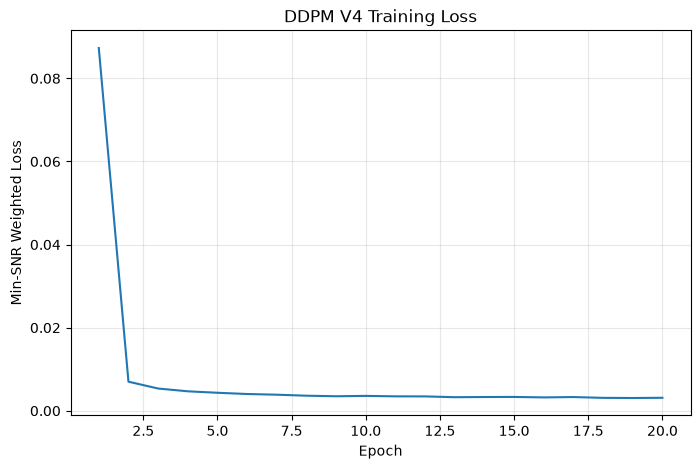

In [20]:
loss_history = np.load(
    "ddpm_v4_checkpoints/"
    "ddpm_loss_history.npy"
)

print(
    "Number of epochs:",
    len(loss_history)
)

for i, loss in enumerate(
    loss_history
):
    print(
        f"Epoch {i + 1:03d} | "
        f"Loss = {loss:.6f}"
    )

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    np.arange(
        1,
        len(loss_history) + 1
    ),
    loss_history
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Min-SNR Weighted Loss"
)

plt.title(
    "DDPM V4 Training Loss"
)

plt.grid(
    alpha=0.3
)

plt.show()

In [21]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = UNet3D(
    in_channels=1,
    out_channels=1,
    base_channels=16,
    time_dim=256
).to(device)

ema = EMA(
    model,
    decay=0.9999
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

loaded_epoch = load_checkpoint(
    model=model,
    ema=ema,
    optimizer=optimizer,
    path=(
        "ddpm_v4_checkpoints/"
        "ddpm_epoch_020.pt"
    ),
    device=device
)

print(
    "Loaded epoch:",
    loaded_epoch
)

Loaded epoch: 20


In [22]:
torch.manual_seed(
    42
)

generated_v4 = sample_ddpm(
    model=ema.ema_model,
    shape=(
        1,
        1,
        208,
        224,
        160
    ),
    device=device
)

print(
    "Generated shape:",
    generated_v4.shape
)

print(
    "Generated min/max:",
    generated_v4.min().item(),
    generated_v4.max().item()
)

Generated shape: torch.Size([1, 1, 208, 224, 160])


Generated min/max: -0.9994723200798035 0.9941945672035217


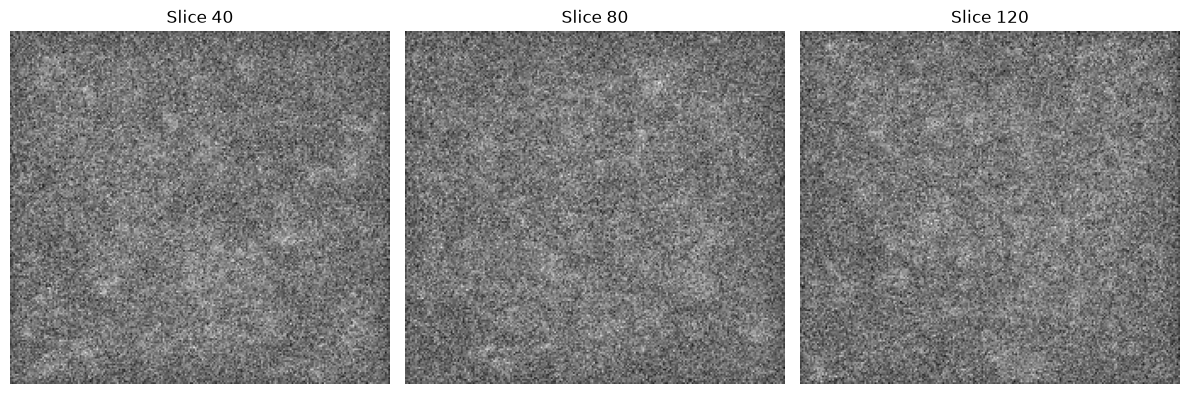

In [23]:
gen = (
    generated_v4[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)

# Convert [-1, 1] -> [0, 1]
gen_display = (
    gen + 1.0
) / 2.0

gen_display = np.clip(
    gen_display,
    0.0,
    1.0
)

slices = [
    40,
    80,
    120
]

plt.figure(
    figsize=(12, 4)
)

for i, z_slice in enumerate(
    slices
):
    plt.subplot(
        1,
        3,
        i + 1
    )

    plt.imshow(
        gen_display[
            :,
            :,
            z_slice
        ],
        cmap="gray",
        vmin=0,
        vmax=1
    )

    plt.title(
        f"Slice {z_slice}"
    )

    plt.axis(
        "off"
    )

plt.tight_layout()

plt.show()

In [24]:
print(
    "Raw [-1,1] statistics"
)

print(
    "Min:",
    gen.min()
)

print(
    "Max:",
    gen.max()
)

print(
    "Mean:",
    gen.mean()
)

print(
    "Std:",
    gen.std()
)

print()

print(
    "Display [0,1] statistics"
)

print(
    "Min:",
    gen_display.min()
)

print(
    "Max:",
    gen_display.max()
)

print(
    "Mean:",
    gen_display.mean()
)

print(
    "Std:",
    gen_display.std()
)

print()

print(
    "P1:",
    np.percentile(
        gen_display,
        1
    )
)

print(
    "P50:",
    np.percentile(
        gen_display,
        50
    )
)

print(
    "P99:",
    np.percentile(
        gen_display,
        99
    )
)

Raw [-1,1] statistics
Min: -0.9994723
Max: 0.99419457
Mean: -0.090967886
Std: 0.23551825

Display [0,1] statistics
Min: 0.00026383996
Max: 0.99709725
Mean: 0.45451605
Std: 0.11775912

P1: 0.18693557
P50: 0.45351297
P99: 0.7314135


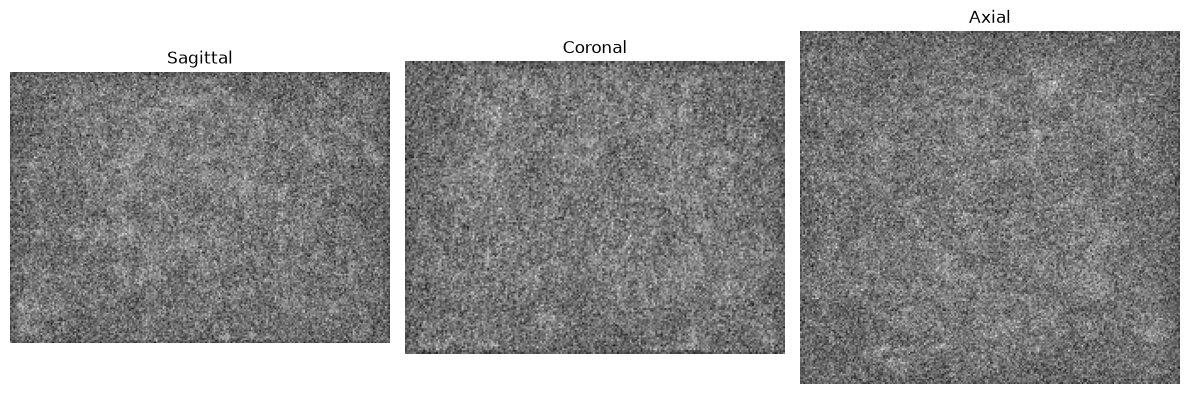

In [25]:
volume = gen_display

x_mid = (
    volume.shape[0] // 2
)

y_mid = (
    volume.shape[1] // 2
)

z_mid = (
    volume.shape[2] // 2
)

plt.figure(
    figsize=(12, 4)
)

plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    volume[
        x_mid,
        :,
        :
    ].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.title(
    "Sagittal"
)

plt.axis(
    "off"
)

plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    volume[
        :,
        y_mid,
        :
    ].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.title(
    "Coronal"
)

plt.axis(
    "off"
)

plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    volume[
        :,
        :,
        z_mid
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Axial"
)

plt.axis(
    "off"
)

plt.tight_layout()

plt.show()